# Edge-BPE timing sweep

This experiment compares the three built-in BPE scoring policies across the
Python and Numba fitting backends on three synthetic tree families:

- **starry**: one high-degree parent per tree;
- **bursty**: a chain of local hubs, each with a small sibling burst;
- **binary / 2-child**: a finite rooted tree with at most two children per node
  (the useful finite-tree interpretation of “2-regular” here).

The requested full grid ranges from **1,000 to 50,000 trees** and from
**50,000 to 5,000,000 total vertices**. The notebook defaults to a small smoke
preset so that “Run All” is safe. Change `PRESET` to `"requested"` for the full
sweep. Five million NetworkX vertices can require many gigabytes of memory, so
run the full preset on an appropriately sized machine.

## 0. Imports and repository package

In [1]:
from pathlib import Path
from time import perf_counter
import gc
import os
import random
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    here = start.resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "tree_coarsening").is_dir():
            return candidate
    raise RuntimeError("Could not locate the tree_coarsening repository root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

for module_name in list(sys.modules):
    if module_name == "tree_coarsening" or module_name.startswith("tree_coarsening."):
        del sys.modules[module_name]

from tree_coarsening import EdgeBPECoarsener
import tree_coarsening

print("Python:", sys.executable)
print("Project root:", PROJECT_ROOT)
print("tree_coarsening:", Path(tree_coarsening.__file__).resolve())

Python: /home/asmi28/anaconda3/envs/steering/bin/python
Project root: /home/asmi28/python_code/tree_coarsening_2
tree_coarsening: /home/asmi28/python_code/tree_coarsening_2/tree_coarsening/__init__.py


## 1. Benchmark grid and controls

In [2]:
SEED = 20260619
NUM_MERGES = 32
MIN_PAIR_COUNT = 2
PAIR_SCORES = ("count", "normalized", "size_weighted")
BACKENDS = ("python", "numba")
REPEATS = 1
VALIDATE_INPUTS = False
TRANSFORM_SAMPLE_TREES = 100
SAVE_RESULTS = True

# Exact scale family requested for the substantive run.
REQUESTED_SCALE_GRID = [
    {"n_trees": 1_000, "total_vertices": 50_000},
    {"n_trees": 5_000, "total_vertices": 250_000},
    {"n_trees": 10_000, "total_vertices": 1_000_000},
    {"n_trees": 50_000, "total_vertices": 5_000_000},
]

PRESETS = {
    # Fast enough for ordinary notebook validation.
    "smoke": [
        {"n_trees": 100, "total_vertices": 5_000},
    ],
    # Reaches the lower requested boundary and one larger case.
    "medium": REQUESTED_SCALE_GRID[:2],
    # Full requested range; use a high-memory machine.
    "requested": REQUESTED_SCALE_GRID,
}

PRESET = "requested"  # change to "medium" or "requested"
SCALE_GRID = PRESETS[PRESET]
SHAPES = ("starry", "bursty", "binary_2_child")

pd.DataFrame(SCALE_GRID).assign(
    average_tree_size=lambda frame: frame.total_vertices / frame.n_trees
)

,n_trees,total_vertices,average_tree_size
0,1000,50000,50.0
1,5000,250000,50.0
2,10000,1000000,100.0
3,50000,5000000,100.0


## 2. Deterministic synthetic corpus generators

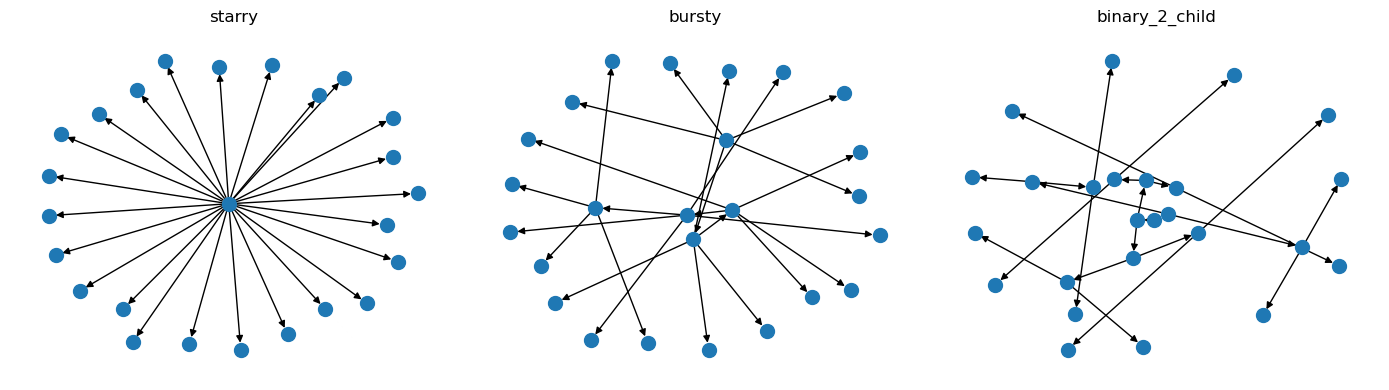

In [3]:
def _node_counts(n_trees: int, total_vertices: int) -> list[int]:
    if n_trees < 1:
        raise ValueError("n_trees must be positive")
    if total_vertices < n_trees:
        raise ValueError("total_vertices must be at least n_trees")
    base, remainder = divmod(total_vertices, n_trees)
    return [base + (tree_index < remainder) for tree_index in range(n_trees)]


def _add_node(graph, node, *, label, time, uid):
    graph.add_node(node, label=label, time=float(time), uid=uid)


def make_starry_tree(n_nodes: int, *, prefix: str) -> nx.DiGraph:
    graph = nx.DiGraph()
    _add_node(graph, 0, label="P", time=0.0, uid=f"{prefix}:0")
    for node in range(1, n_nodes):
        _add_node(graph, node, label="S", time=node, uid=f"{prefix}:{node}")
        graph.add_edge(0, node)
    return graph


def make_bursty_tree(n_nodes: int, *, prefix: str, burst_width: int = 4) -> nx.DiGraph:
    """Backbone of hub nodes, each with a small same-label sibling burst."""

    graph = nx.DiGraph()
    _add_node(graph, 0, label="R", time=0.0, uid=f"{prefix}:0")
    if n_nodes == 1:
        return graph

    next_node = 1
    hub = 0
    burst_index = 0
    while next_node < n_nodes:
        # Reserve one slot for the continuation hub when possible.
        remaining = n_nodes - next_node
        leaf_count = min(burst_width, max(0, remaining - 1))
        for _ in range(leaf_count):
            node = next_node
            next_node += 1
            _add_node(
                graph,
                node,
                label="B",
                time=node,
                uid=f"{prefix}:{node}",
            )
            graph.add_edge(hub, node)
        if next_node >= n_nodes:
            break
        continuation = next_node
        next_node += 1
        _add_node(
            graph,
            continuation,
            label="H0" if burst_index % 2 == 0 else "H1",
            time=continuation,
            uid=f"{prefix}:{continuation}",
        )
        graph.add_edge(hub, continuation)
        hub = continuation
        burst_index += 1
    return graph


def make_binary_tree(n_nodes: int, *, prefix: str) -> nx.DiGraph:
    graph = nx.DiGraph()
    for node in range(n_nodes):
        depth = (node + 1).bit_length() - 1
        _add_node(
            graph,
            node,
            label=("A", "B", "C")[depth % 3],
            time=node,
            uid=f"{prefix}:{node}",
        )
        if node:
            graph.add_edge((node - 1) // 2, node)
    return graph


TREE_BUILDERS = {
    "starry": make_starry_tree,
    "bursty": make_bursty_tree,
    "binary_2_child": make_binary_tree,
}


def make_corpus(shape: str, *, n_trees: int, total_vertices: int, seed: int):
    # The seed is part of the public benchmark record even though these three
    # shape constructors are deterministic today. It leaves room for controlled
    # random label/noise variants later without changing the notebook interface.
    random.Random(seed)
    counts = _node_counts(n_trees, total_vertices)
    builder = TREE_BUILDERS[shape]
    return [
        builder(n_nodes, prefix=f"{shape}:{seed}:{tree_index}")
        for tree_index, n_nodes in enumerate(counts)
    ]


# Tiny visual sanity check.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, shape in zip(axes, SHAPES, strict=True):
    graph = make_corpus(shape, n_trees=1, total_vertices=25, seed=SEED)[0]
    positions = nx.spring_layout(graph, seed=SEED)
    nx.draw_networkx(graph, positions, node_size=100, with_labels=False, ax=axis)
    axis.set_title(shape)
    axis.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Explicit Numba warm-up

In [4]:
NUMBA_AVAILABLE = True
try:
    import numba  # noqa: F401
except ImportError:
    NUMBA_AVAILABLE = False

numba_warmup_rows = []
if "numba" in BACKENDS and NUMBA_AVAILABLE:
    warmup_corpus = make_corpus(
        "binary_2_child",
        n_trees=4,
        total_vertices=1_000,
        seed=SEED,
    )
    for pair_score in PAIR_SCORES:
        start = perf_counter()
        EdgeBPECoarsener(
            num_merges=4,
            min_pair_count=2,
            pair_score=pair_score,
            backend="numba",
            validate_inputs=False,
            model_id=f"numba-warmup-{pair_score}",
        ).fit(warmup_corpus)
        numba_warmup_rows.append(
            {"pair_score": pair_score, "warmup_seconds": perf_counter() - start}
        )
    del warmup_corpus
    gc.collect()
else:
    print("Numba is not installed; Numba benchmark rows will be skipped.")

pd.DataFrame(numba_warmup_rows)

,pair_score,warmup_seconds
0,count,0.662263
1,normalized,0.004742
2,size_weighted,0.004446


## 4. Run the sweep

Generation is timed separately. Each backend/scorer combination fits the same
corpus. Transform timing uses at most `TRANSFORM_SAMPLE_TREES` trees so that the
full 5-million-vertex fit does not automatically duplicate the entire corpus in
memory.

In [5]:
def benchmark_model(
    corpus,
    *,
    shape,
    n_trees,
    total_vertices,
    generation_seconds,
    pair_score,
    backend,
    repeat,
):
    model = EdgeBPECoarsener(
        num_merges=NUM_MERGES,
        min_pair_count=MIN_PAIR_COUNT,
        pair_score=pair_score,
        backend=backend,
        validate_inputs=VALIDATE_INPUTS,
        model_id=f"bench-{shape}-{backend}-{pair_score}-{repeat}",
    )

    gc.collect()
    start = perf_counter()
    model.fit(corpus)
    fit_seconds = perf_counter() - start

    sample = corpus[: min(TRANSFORM_SAMPLE_TREES, len(corpus))]
    sample_input_nodes = sum(graph.number_of_nodes() for graph in sample)
    start = perf_counter()
    encoded_sample = model.transform(sample, validate=False)
    transform_seconds = perf_counter() - start
    sample_output_nodes = sum(graph.number_of_nodes() for graph in encoded_sample)

    row = {
        "preset": PRESET,
        "shape": shape,
        "n_trees": n_trees,
        "total_vertices": total_vertices,
        "average_tree_size": total_vertices / n_trees,
        "generation_seconds": generation_seconds,
        "pair_score": pair_score,
        "backend_requested": backend,
        "backend_used": model.backend_used_,
        "repeat": repeat,
        "fit_seconds": fit_seconds,
        "n_rules": len(model.history_),
        "transform_sample_trees": len(sample),
        "transform_sample_input_nodes": sample_input_nodes,
        "transform_sample_output_nodes": sample_output_nodes,
        "transform_seconds": transform_seconds,
        "sample_compression_ratio": sample_output_nodes / sample_input_nodes,
    }
    del encoded_sample, model
    gc.collect()
    return row


results = []
for scale_index, scale in enumerate(SCALE_GRID):
    for shape_index, shape in enumerate(SHAPES):
        case_seed = SEED + 10_000 * scale_index + shape_index
        print(
            f"Generating {shape}: {scale['n_trees']:,} trees / "
            f"{scale['total_vertices']:,} vertices"
        )
        start = perf_counter()
        corpus = make_corpus(shape, seed=case_seed, **scale)
        generation_seconds = perf_counter() - start
        assert sum(graph.number_of_nodes() for graph in corpus) == scale["total_vertices"]

        for pair_score in PAIR_SCORES:
            for backend in BACKENDS:
                if backend == "numba" and not NUMBA_AVAILABLE:
                    continue
                for repeat in range(REPEATS):
                    row = benchmark_model(
                        corpus,
                        shape=shape,
                        generation_seconds=generation_seconds,
                        pair_score=pair_score,
                        backend=backend,
                        repeat=repeat,
                        **scale,
                    )
                    results.append(row)
                    print(
                        f"  {backend:6} {pair_score:13} "
                        f"fit={row['fit_seconds']:.3f}s "
                        f"rules={row['n_rules']:2d}"
                    )
        del corpus
        gc.collect()

results_df = pd.DataFrame(results)
results_df

Generating starry: 1,000 trees / 50,000 vertices
  python count         fit=0.835s rules=32
  numba  count         fit=0.578s rules=32
  python normalized    fit=0.829s rules=32
  numba  normalized    fit=0.571s rules=32
  python size_weighted fit=0.830s rules=32
  numba  size_weighted fit=0.581s rules=32
Generating bursty: 1,000 trees / 50,000 vertices
  python count         fit=0.467s rules=20
  numba  count         fit=0.360s rules=20
  python normalized    fit=0.453s rules=21
  numba  normalized    fit=0.360s rules=21
  python size_weighted fit=0.442s rules=20
  numba  size_weighted fit=0.354s rules=20
Generating binary_2_child: 1,000 trees / 50,000 vertices
  python count         fit=0.442s rules=20
  numba  count         fit=0.347s rules=20
  python normalized    fit=0.443s rules=14
  numba  normalized    fit=0.350s rules=14
  python size_weighted fit=0.440s rules=23
  numba  size_weighted fit=0.351s rules=23
Generating starry: 5,000 trees / 250,000 vertices
  python count       

,preset,shape,n_trees,total_vertices,average_tree_size,generation_seconds,pair_score,backend_requested,backend_used,repeat,fit_seconds,n_rules,transform_sample_trees,transform_sample_input_nodes,transform_sample_output_nodes,transform_seconds,sample_compression_ratio
0,requested,starry,1000,50000,50.0,0.043576,count,python,python,0,0.835351,32,100,5000,1800,0.086737,0.36
1,requested,starry,1000,50000,50.0,0.043576,count,numba,numba,0,0.577741,32,100,5000,1800,0.087185,0.36
2,requested,starry,1000,50000,50.0,0.043576,normalized,python,python,0,0.828860,32,100,5000,1800,0.088325,0.36
3,requested,starry,1000,50000,50.0,0.043576,normalized,numba,numba,0,0.571248,32,100,5000,1800,0.087144,0.36
4,requested,starry,1000,50000,50.0,0.043576,size_weighted,python,python,0,0.829799,32,100,5000,1800,0.086676,0.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,requested,binary_2_child,50000,5000000,100.0,10.079753,count,numba,numba,0,37.372608,27,100,10000,100,0.124677,0.01
68,requested,binary_2_child,50000,5000000,100.0,10.079753,normalized,python,python,0,53.069173,23,100,10000,100,0.123943,0.01
69,requested,binary_2_child,50000,5000000,100.0,10.079753,normalized,numba,numba,0,38.806484,23,100,10000,100,0.126235,0.01
70,requested,binary_2_child,50000,5000000,100.0,10.079753,size_weighted,python,python,0,54.290808,32,100,10000,1400,0.122187,0.14


## 5. Aggregate results and save CSV

In [6]:
if results_df.empty:
    raise RuntimeError("No benchmark rows were produced.")

summary_df = (
    results_df.groupby(
        [
            "shape",
            "n_trees",
            "total_vertices",
            "pair_score",
            "backend_used",
        ],
        as_index=False,
    )
    .agg(
        fit_seconds=("fit_seconds", "median"),
        transform_seconds=("transform_seconds", "median"),
        n_rules=("n_rules", "median"),
        sample_compression_ratio=("sample_compression_ratio", "median"),
        generation_seconds=("generation_seconds", "median"),
    )
)

if SAVE_RESULTS:
    results_dir = PROJECT_ROOT / "experiments" / "results"
    results_dir.mkdir(parents=True, exist_ok=True)
    output_csv = results_dir / f"edge_bpe_timing_{PRESET}.csv"
    results_df.to_csv(output_csv, index=False)
    print("Saved:", output_csv)

display(summary_df)

Saved: /home/asmi28/python_code/tree_coarsening_2/experiments/results/edge_bpe_timing_requested.csv


,shape,n_trees,total_vertices,pair_score,backend_used,fit_seconds,transform_seconds,n_rules,sample_compression_ratio,generation_seconds
0,binary_2_child,1000,50000,count,numba,0.347136,0.066401,20.0,0.02,0.036053
1,binary_2_child,1000,50000,count,python,0.442400,0.064692,20.0,0.02,0.036053
2,binary_2_child,1000,50000,normalized,numba,0.349760,0.063778,14.0,0.02,0.036053
3,binary_2_child,1000,50000,normalized,python,0.442525,0.063676,14.0,0.02,0.036053
4,binary_2_child,1000,50000,size_weighted,numba,0.351302,0.064906,23.0,0.02,0.036053
...,...,...,...,...,...,...,...,...,...,...
67,starry,50000,5000000,count,python,98.249436,0.177222,32.0,0.68,9.018412
68,starry,50000,5000000,normalized,numba,70.535154,0.178481,32.0,0.68,9.018412
69,starry,50000,5000000,normalized,python,97.295657,0.177702,32.0,0.68,9.018412
70,starry,50000,5000000,size_weighted,numba,70.234614,0.178426,32.0,0.68,9.018412


## 6. Fit-time curves

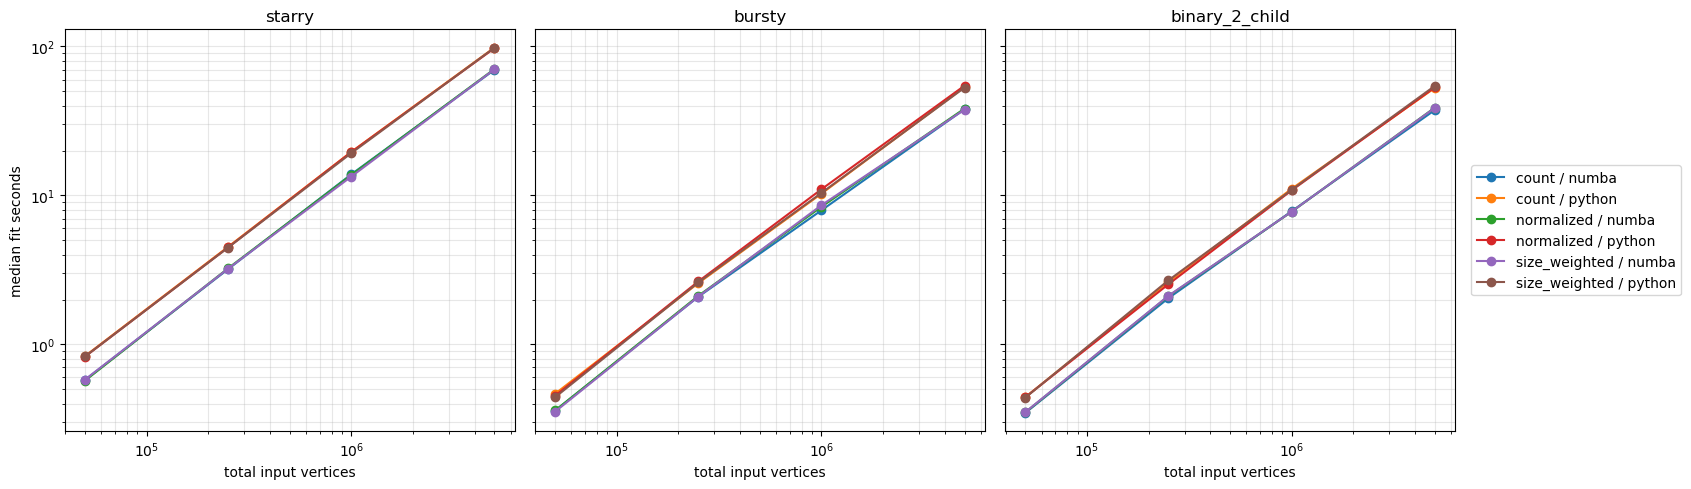

In [7]:
fig, axes = plt.subplots(1, len(SHAPES), figsize=(17, 5), sharey=True)
if len(SHAPES) == 1:
    axes = [axes]

for axis, shape in zip(axes, SHAPES, strict=True):
    subset = summary_df[summary_df["shape"] == shape]
    for (pair_score, backend), group in subset.groupby(["pair_score", "backend_used"]):
        group = group.sort_values("total_vertices")
        axis.plot(
            group["total_vertices"],
            group["fit_seconds"],
            marker="o",
            label=f"{pair_score} / {backend}",
        )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_title(shape)
    axis.set_xlabel("total input vertices")
    axis.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("median fit seconds")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

## 7. Warm Numba speedup and transformation timing

In [8]:
python_rows = summary_df[summary_df.backend_used == "python"].rename(
    columns={"fit_seconds": "python_fit_seconds"}
)
numba_rows = summary_df[summary_df.backend_used == "numba"].rename(
    columns={"fit_seconds": "numba_fit_seconds"}
)
join_keys = ["shape", "n_trees", "total_vertices", "pair_score"]
speedup_df = python_rows.merge(numba_rows, on=join_keys, suffixes=("_python", "_numba"))
if not speedup_df.empty:
    speedup_df["numba_speedup"] = (
        speedup_df["python_fit_seconds"] / speedup_df["numba_fit_seconds"]
    )
    display(
        speedup_df[
            join_keys + ["python_fit_seconds", "numba_fit_seconds", "numba_speedup"]
        ].sort_values("numba_speedup", ascending=False)
    )

transform_view = summary_df[
    [
        "shape",
        "total_vertices",
        "pair_score",
        "backend_used",
        "transform_seconds",
        "sample_compression_ratio",
    ]
].sort_values(["shape", "total_vertices", "pair_score", "backend_used"])
display(transform_view)

,shape,n_trees,total_vertices,pair_score,python_fit_seconds,numba_fit_seconds,numba_speedup
25,starry,1000,50000,normalized,0.828860,0.571248,1.450962
24,starry,1000,50000,count,0.835351,0.577741,1.445893
32,starry,10000,1000000,size_weighted,19.242068,13.386933,1.437377
26,starry,1000,50000,size_weighted,0.829799,0.580888,1.428502
31,starry,10000,1000000,normalized,19.583954,13.738697,1.425459
22,bursty,50000,5000000,normalized,54.578919,38.298213,1.425104
6,binary_2_child,10000,1000000,count,11.080912,7.832388,1.414755
30,starry,10000,1000000,count,19.603459,13.857277,1.414669
27,starry,5000,250000,count,4.521004,3.201412,1.412191
21,bursty,50000,5000000,count,53.438571,37.898300,1.410052


,shape,total_vertices,pair_score,backend_used,transform_seconds,sample_compression_ratio
0,binary_2_child,50000,count,numba,0.066401,0.02
1,binary_2_child,50000,count,python,0.064692,0.02
2,binary_2_child,50000,normalized,numba,0.063778,0.02
3,binary_2_child,50000,normalized,python,0.063676,0.02
4,binary_2_child,50000,size_weighted,numba,0.064906,0.02
...,...,...,...,...,...,...
67,starry,5000000,count,python,0.177222,0.68
68,starry,5000000,normalized,numba,0.178481,0.68
69,starry,5000000,normalized,python,0.177702,0.68
70,starry,5000000,size_weighted,numba,0.178426,0.68


## 8. Interpretation checklist

When reviewing results, distinguish:

- corpus-generation time from fit time;
- first-call Numba compilation from warmed Numba fits;
- high-overlap starry trees, where raw pair count can greatly exceed actual
  contraction events;
- scorer-dependent rule order (`count`, `normalized`, and `size_weighted`);
- fit-time improvements from output compression, which can differ substantially
  between shapes.
